# Importación de librerías

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Caraga de Datos

In [6]:
df = pd.read_csv("C:\SmartCityIA\data\Estadisticas OIJ.csv")

df.head()

,Delito,SubDelito,Fecha,Rango Horario,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton
0,ASALTO,ARMA BLANCA,01/02/2022,12:00:00 - 14:59:59,VEHICULO,MOTOCICLETA/REPARTIDOR [VEHICULO],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,ASERRI
1,ASALTO,ARMA BLANCA,03/02/2022,18:00:00 - 20:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,ALAJUELA,ALAJUELA
2,ASALTO,ARMA BLANCA,04/02/2022,09:00:00 - 11:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE
3,ASALTO,ARMA BLANCA,06/02/2022,03:00:00 - 05:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE
4,ASALTO,ARMA BLANCA,08/02/2022,00:00:00 - 02:59:59,PERSONA,TURISTA/EXTRANJERO [PERSONA],Mayor de edad,HOMBRE,RUSIA,PUNTARENAS,GARABITO


# Limpieza de datos

In [12]:
df.columns = df.columns.str.strip()

df["Fecha"] = pd.to_datetime(df["Fecha"], dayfirst=True, errors='coerce')

cols_texto = ["Delito", "SubDelito", "Provincia", "Canton", "Sexo"]
for col in cols_texto:
    df[col] = df[col].astype(str).str.strip().str.upper()

df["Edad"] = pd.to_numeric(df["Edad"], errors='coerce')

df = df.dropna(subset=["Fecha", "Delito"])

print("\nDatos después de limpieza:")
df.info()

df = df.applymap(lambda x: str(x).strip().upper() if isinstance(x, str) else x)

df = df[~df.isin(["DESCONOCIDO"]).any(axis=1)]

print("Nuevo tamaño del dataset:", df.shape)


Datos después de limpieza:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173432 entries, 0 to 173431
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Delito         173432 non-null  object        
 1   SubDelito      173432 non-null  object        
 2   Fecha          173432 non-null  datetime64[ns]
 3   Rango Horario  173432 non-null  object        
 4   Victima        173432 non-null  object        
 5   SubVictima     173432 non-null  object        
 6   Edad           0 non-null       float64       
 7   Sexo           173432 non-null  object        
 8   Nacionalidad   173432 non-null  object        
 9   Provincia      173432 non-null  object        
 10  Canton         173432 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(9)
memory usage: 14.6+ MB


C:\Users\Roberto\AppData\Local\Temp\ipykernel_24796\3942425347.py:22: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: str(x).strip().upper() if isinstance(x, str) else x)


Nuevo tamaño del dataset: (166630, 11)


# Analisis General

In [13]:
print("\nTop delitos:")
print(df["Delito"].value_counts().head(10))

print("\nTop provincias:")
print(df["Provincia"].value_counts())


Top delitos:
Delito
HURTO                55545
ASALTO               42081
ROBO                 32522
ROBO DE VEHICULO     18596
TACHA DE VEHICULO    14959
HOMICIDIO             2927
Name: count, dtype: int64

Top provincias:
Provincia
SAN JOSE      63168
ALAJUELA      26542
PUNTARENAS    20174
GUANACASTE    15957
LIMON         14821
HEREDIA       13801
CARTAGO       12167
Name: count, dtype: int64


# Delitos mas frecuentes

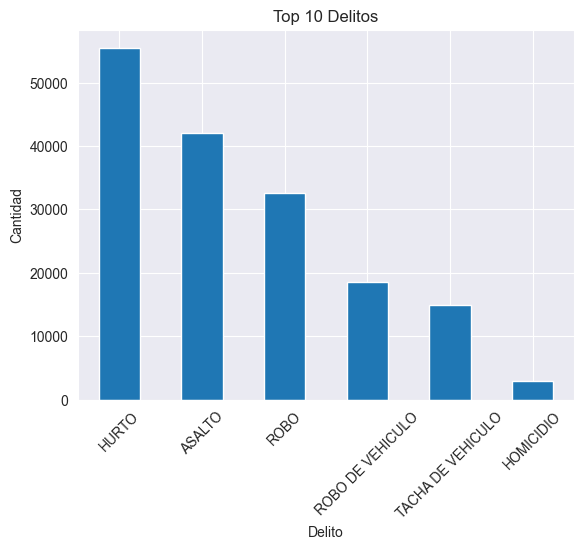

In [14]:
top_delitos = df["Delito"].value_counts().head(10)

plt.figure()
top_delitos.plot(kind='bar')
plt.title("Top 10 Delitos")
plt.xlabel("Delito")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

# Analisis por genero

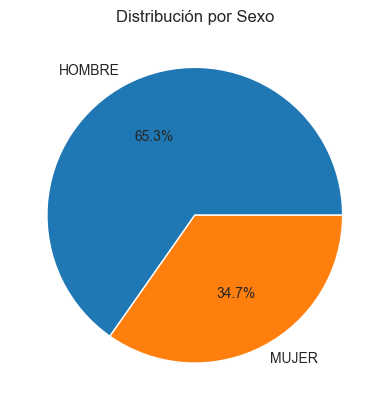

In [15]:
sexo_counts = df["Sexo"].value_counts()

plt.figure()
sexo_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribución por Sexo")
plt.ylabel("")
plt.show()

# Top Provincias

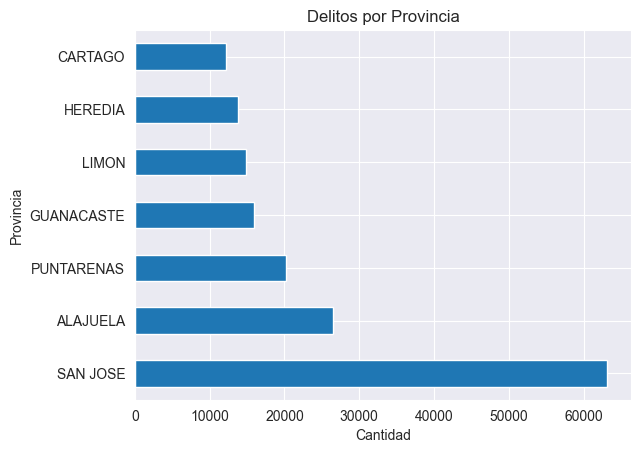

In [16]:
prov_counts = df["Provincia"].value_counts()

plt.figure()
prov_counts.plot(kind='barh')
plt.title("Delitos por Provincia")
plt.xlabel("Cantidad")
plt.show()

# Conclusiones

In [18]:
print("\n Conclusiones")

print("Delito más común:", df["Delito"].value_counts().idxmax())
print("Provincia con más delitos:", df["Provincia"].value_counts().idxmax())
print("Genero con más delitos:", df["Sexo"].value_counts().idxmax())


 Conclusiones
Delito más común: HURTO
Provincia con más delitos: SAN JOSE
Genero con más delitos: HOMBRE
